# 🏥 ICU-Watch — Exploratory Data Analysis
**Dataset:** PhysioNet Sepsis Challenge 2019
**Author:** Subham Pal

### Goals of this notebook
1. Understand the dataset structure and patient population
2. Analyze vital sign distributions
3. Understand class imbalance (sepsis vs non-sepsis)
4. Identify missing data patterns
5. Explore temporal patterns in deteriorating patients
6. Inform feature engineering decisions

## 0. Setup & Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

# Paths
DATA_DIR = Path('../data/raw/training')
SET_A    = DATA_DIR / 'training_setA'
SET_B    = DATA_DIR / 'training_setB'

print('Setup complete')
print(f'Set A patients: {len(list(SET_A.glob("*.psv")))}')  
print(f'Set B patients: {len(list(SET_B.glob("*.psv")))}')

Setup complete
Set A patients: 20336
Set B patients: 20000


## 1. Understand the Data Structure

In [2]:
# Load a single patient file to understand structure
sample_file = list(SET_A.glob('*.psv'))[0]
sample_df = pd.read_csv(sample_file, sep='|')

print(f'Sample file: {sample_file.name}')
print(f'Shape: {sample_df.shape} — {sample_df.shape[0]} hours, {sample_df.shape[1]} columns')
print(f'\nColumns ({len(sample_df.columns)}):')
print(sample_df.columns.tolist())
print(f'\nFirst 5 rows:')
sample_df.head()

Sample file: p000001.psv
Shape: (54, 41) — 54 hours, 41 columns

Columns (41):
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']

First 5 rows:


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0


In [3]:
# Our key vital signs for ICU-Watch
VITALS = [
    'HR',           # Heart Rate
    'O2Sat',        # SpO2
    'Temp',         # Temperature
    'SBP',          # Systolic Blood Pressure
    'MAP',          # Mean Arterial Pressure  
    'DBP',          # Diastolic Blood Pressure
    'Resp',         # Respiratory Rate
    'EtCO2',        # End-tidal CO2
]

LAB_VALUES = [
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2',
    'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride',
    'Creatinine', 'Glucose', 'Lactate', 'Magnesium',
    'Phosphate', 'Potassium', 'Bilirubin_total', 'Hct',
    'Hgb', 'PTT', 'WBC', 'Platelets'
]

DEMOGRAPHICS = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']
TARGET = 'SepsisLabel'

print(f'Vital signs tracked: {len(VITALS)}')
print(f'Lab values tracked: {len(LAB_VALUES)}')
print(f'Target column: {TARGET}')
print(f'\nSepsis labels in sample patient:')
print(sample_df[TARGET].value_counts())

Vital signs tracked: 8
Lab values tracked: 23
Target column: SepsisLabel

Sepsis labels in sample patient:
SepsisLabel
0    54
Name: count, dtype: int64


## 2. Load Full Dataset

In [4]:
def load_all_patients(data_dir: Path, max_patients: int = None) -> pd.DataFrame:
    """
    Load all patient PSV files into a single DataFrame.
    Adds patient_id and set label columns.
    """
    dfs = []
    files = list(data_dir.glob('*.psv'))
    if max_patients:
        files = files[:max_patients]
    
    for f in tqdm(files, desc=f'Loading {data_dir.name}'):
        df = pd.read_csv(f, sep='|')
        df['patient_id'] = f.stem
        df['hour'] = range(len(df))
        dfs.append(df)
    
    return pd.concat(dfs, ignore_index=True)

# Load both sets (this takes ~2-3 minutes)
print('Loading Set A...')
df_a = load_all_patients(SET_A)
df_a['dataset'] = 'A'

print('Loading Set B...')
df_b = load_all_patients(SET_B)
df_b['dataset'] = 'B'

# Combine
df = pd.concat([df_a, df_b], ignore_index=True)

print(f'\nFull dataset loaded!')
print(f'Total rows: {len(df):,}')
print(f'Total patients: {df["patient_id"].nunique():,}')
print(f'Total columns: {len(df.columns)}')

Loading Set A...


Loading training_setA: 100%|███████████████████████████████████| 20336/20336 [07:28<00:00, 45.39it/s]


Loading Set B...


Loading training_setB: 100%|███████████████████████████████████| 20000/20000 [07:19<00:00, 45.49it/s]



Full dataset loaded!
Total rows: 1,552,210
Total patients: 40,336
Total columns: 44


## 3. Patient-Level Statistics

In [5]:
# Build patient-level summary
patient_summary = df.groupby('patient_id').agg(
    icu_hours     = ('hour', 'max'),
    sepsis_label  = ('SepsisLabel', 'max'),  # 1 if ever had sepsis
    sepsis_onset  = ('SepsisLabel', 'idxmax'),
    age           = ('Age', 'first'),
    gender        = ('Gender', 'first'),
    dataset       = ('dataset', 'first'),
).reset_index()

n_sepsis     = patient_summary['sepsis_label'].sum()
n_no_sepsis  = len(patient_summary) - n_sepsis
sepsis_rate  = n_sepsis / len(patient_summary) * 100

print('=== PATIENT POPULATION OVERVIEW ===')
print(f'Total patients:        {len(patient_summary):,}')
print(f'Sepsis patients:       {n_sepsis:,} ({sepsis_rate:.1f}%)')
print(f'Non-sepsis patients:   {n_no_sepsis:,} ({100-sepsis_rate:.1f}%)')
print(f'Class imbalance ratio: 1:{n_no_sepsis//n_sepsis}')
print(f'\nICU stay duration (hours):')
print(patient_summary['icu_hours'].describe())

=== PATIENT POPULATION OVERVIEW ===
Total patients:        40,336
Sepsis patients:       2,932 (7.3%)
Non-sepsis patients:   37,404 (92.7%)
Class imbalance ratio: 1:12

ICU stay duration (hours):
count    40336.000000
mean        37.482001
std         22.795923
min          7.000000
25%         23.000000
50%         37.000000
75%         46.000000
max        335.000000
Name: icu_hours, dtype: float64


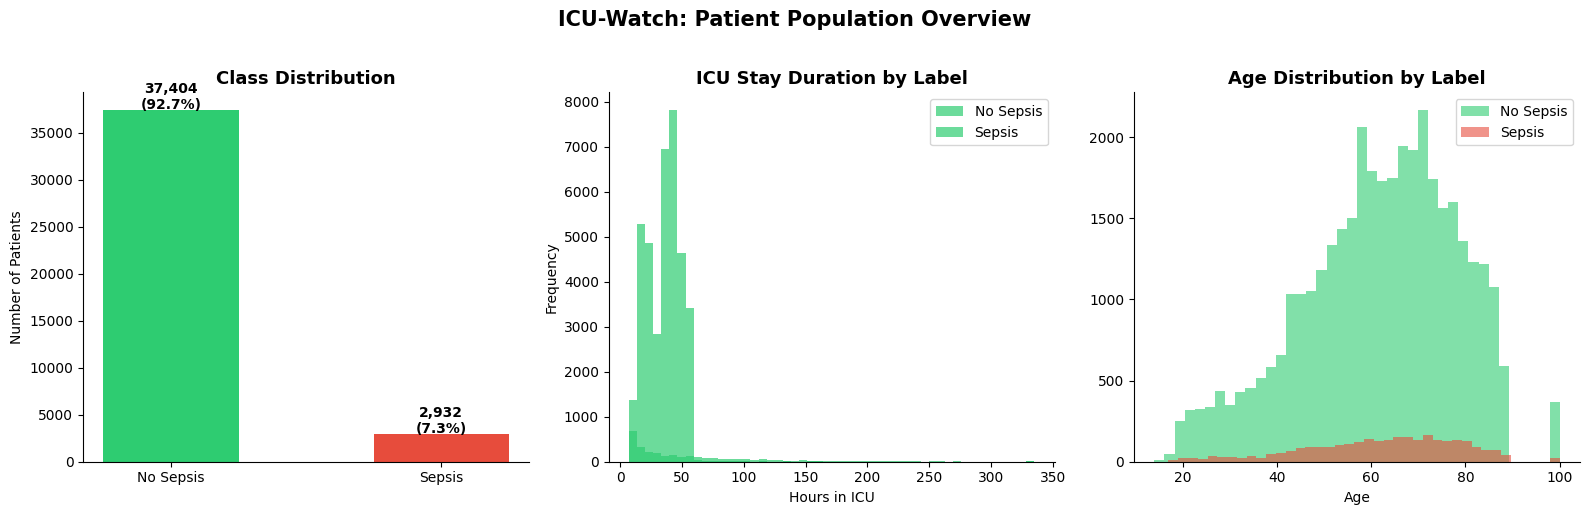

Plot saved to research/notes/


In [6]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Class distribution
labels = ['No Sepsis', 'Sepsis']
counts = [n_no_sepsis, n_sepsis]
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(labels, counts, color=colors, width=0.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(patient_summary)*100:.1f}%)', 
                ha='center', fontweight='bold')

# ICU stay duration by label
patient_summary.groupby('sepsis_label')['icu_hours'].plot(
    kind='hist', bins=50, alpha=0.7, ax=axes[1], 
    color=['#2ecc71', '#e74c3c'], legend=True
)
axes[1].set_title('ICU Stay Duration by Label', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hours in ICU')
axes[1].legend(['No Sepsis', 'Sepsis'])

# Age distribution
for label, color, name in [(0,'#2ecc71','No Sepsis'),(1,'#e74c3c','Sepsis')]:
    subset = patient_summary[patient_summary['sepsis_label']==label]['age'].dropna()
    axes[2].hist(subset, bins=40, alpha=0.6, color=color, label=name)
axes[2].set_title('Age Distribution by Label', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].legend()

plt.suptitle('ICU-Watch: Patient Population Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../research/notes/eda_population.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to research/notes/')

## 4. Vital Sign Distributions

In [7]:
# Vital sign statistics
print('=== VITAL SIGN STATISTICS ===')
vital_stats = df[VITALS].describe().T
vital_stats['missing_%'] = (df[VITALS].isnull().sum() / len(df) * 100).values
vital_stats = vital_stats[['count', 'mean', 'std', 'min', '50%', 'max', 'missing_%']]
vital_stats.columns = ['Count', 'Mean', 'Std', 'Min', 'Median', 'Max', 'Missing %']
vital_stats = vital_stats.round(2)
print(vital_stats.to_string())

=== VITAL SIGN STATISTICS ===
           Count    Mean    Std   Min  Median    Max  Missing %
HR     1398811.0   84.58  17.33  20.0    83.5  280.0       9.88
O2Sat  1349474.0   97.19   2.94  20.0    98.0  100.0      13.06
Temp    525226.0   36.98   0.77  20.9    37.0   50.0      66.16
SBP    1325945.0  123.75  23.23  20.0   121.0  300.0      14.58
MAP    1358940.0   82.40  16.34  20.0    80.0  300.0      12.45
DBP    1065656.0   63.83  13.96  20.0    62.0  300.0      31.35
Resp   1313875.0   18.73   5.10   1.0    18.0  100.0      15.35
EtCO2    57636.0   32.96   7.95  10.0    33.0  100.0      96.29


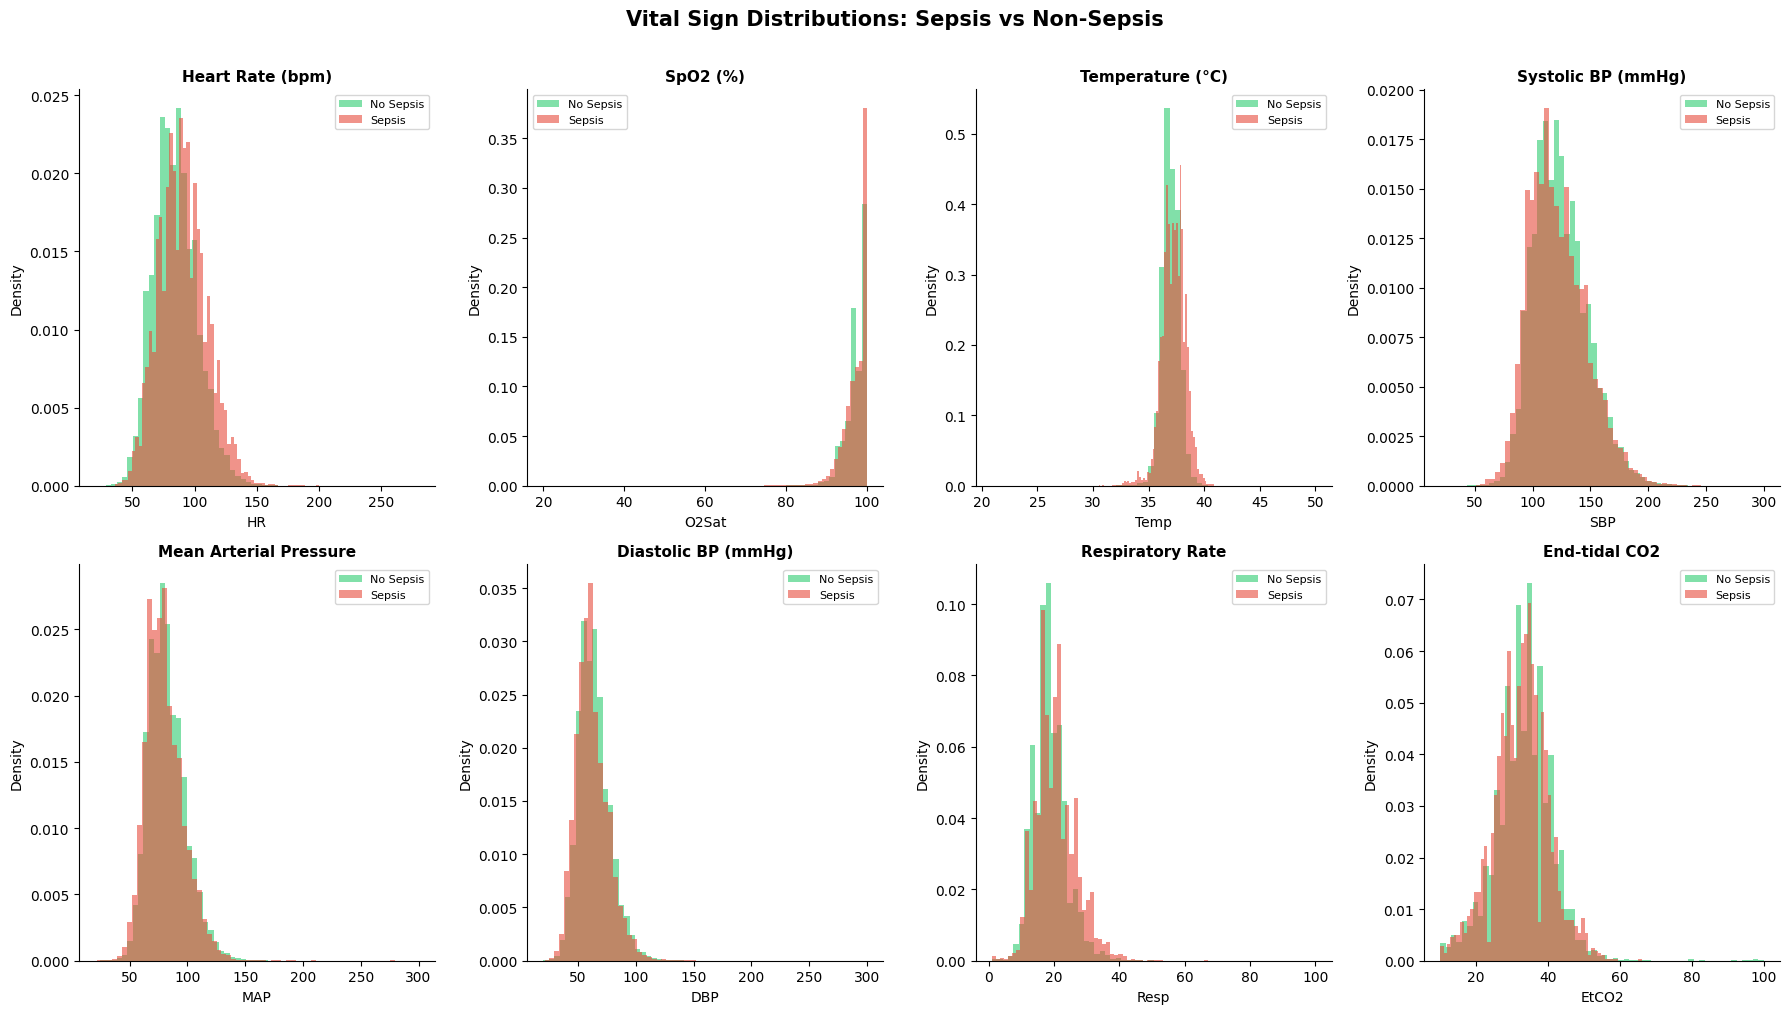

In [8]:
# Vital sign distributions: sepsis vs non-sepsis
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

vital_labels = {
    'HR': 'Heart Rate (bpm)',
    'O2Sat': 'SpO2 (%)',
    'Temp': 'Temperature (°C)',
    'SBP': 'Systolic BP (mmHg)',
    'MAP': 'Mean Arterial Pressure',
    'DBP': 'Diastolic BP (mmHg)',
    'Resp': 'Respiratory Rate',
    'EtCO2': 'End-tidal CO2',
}

for i, (vital, label) in enumerate(vital_labels.items()):
    ax = axes[i]
    for sep_label, color, name in [(0,'#2ecc71','No Sepsis'),(1,'#e74c3c','Sepsis')]:
        data = df[df['SepsisLabel']==sep_label][vital].dropna()
        ax.hist(data, bins=60, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(vital)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Vital Sign Distributions: Sepsis vs Non-Sepsis', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../research/notes/eda_vitals_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Missing Data Analysis

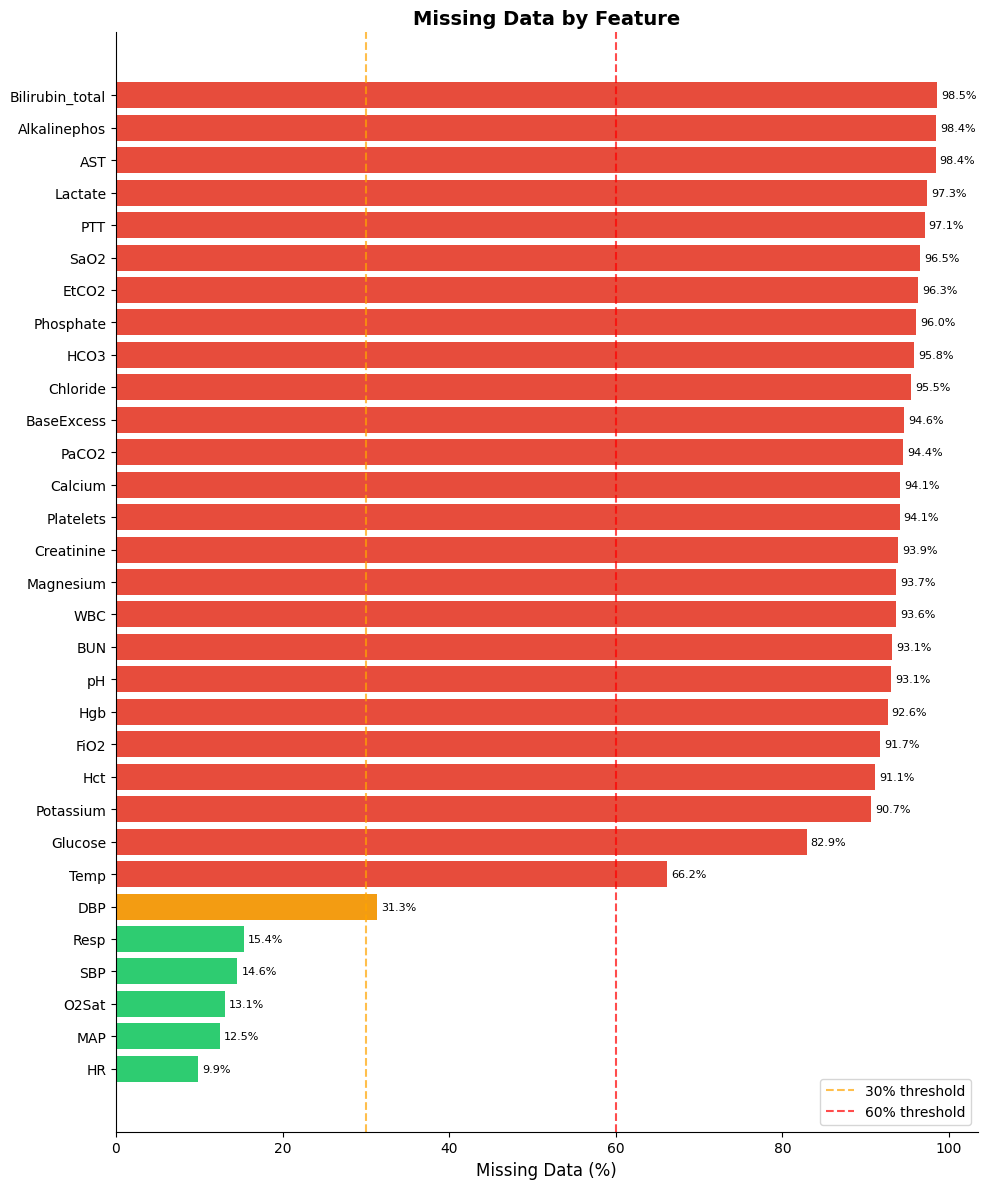


Features with < 30% missing (good for modeling):
['HR', 'MAP', 'O2Sat', 'SBP', 'Resp']


In [9]:
# Missing data heatmap
all_features = VITALS + LAB_VALUES
missing_pct = df[all_features].isnull().mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#2ecc71' if x < 30 else '#f39c12' if x < 60 else '#e74c3c' 
          for x in missing_pct.values]
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors)
ax.axvline(x=30, color='orange', linestyle='--', alpha=0.7, label='30% threshold')
ax.axvline(x=60, color='red', linestyle='--', alpha=0.7, label='60% threshold')
ax.set_xlabel('Missing Data (%)', fontsize=12)
ax.set_title('Missing Data by Feature', fontsize=14, fontweight='bold')
ax.legend()

for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../research/notes/eda_missing_data.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeatures with < 30% missing (good for modeling):')
print(missing_pct[missing_pct < 30].index.tolist())

## 6. Temporal Patterns — How Vitals Change Before Sepsis Onset

In [10]:
# For sepsis patients: align time to sepsis onset (hour 0 = sepsis onset)
# Look at vitals in the 12 hours BEFORE sepsis

def get_pre_sepsis_vitals(df, hours_before=12):
    """Extract vital sign trajectories in hours leading up to sepsis onset."""
    results = []
    
    sepsis_patients = df[df['SepsisLabel']==1]['patient_id'].unique()
    
    for pid in tqdm(sepsis_patients[:500], desc='Processing sepsis patients'):  
        patient = df[df['patient_id']==pid].copy()
        onset_hour = patient[patient['SepsisLabel']==1]['hour'].min()
        
        # Get hours before onset
        pre_sepsis = patient[
            (patient['hour'] >= onset_hour - hours_before) & 
            (patient['hour'] <= onset_hour)
        ].copy()
        pre_sepsis['hours_to_sepsis'] = pre_sepsis['hour'] - onset_hour
        results.append(pre_sepsis)
    
    return pd.concat(results, ignore_index=True)

pre_sepsis_df = get_pre_sepsis_vitals(df, hours_before=12)
print(f'Pre-sepsis records: {len(pre_sepsis_df):,}')

Processing sepsis patients: 100%|██████████████████████████████████| 500/500 [00:29<00:00, 16.93it/s]

Pre-sepsis records: 5,154


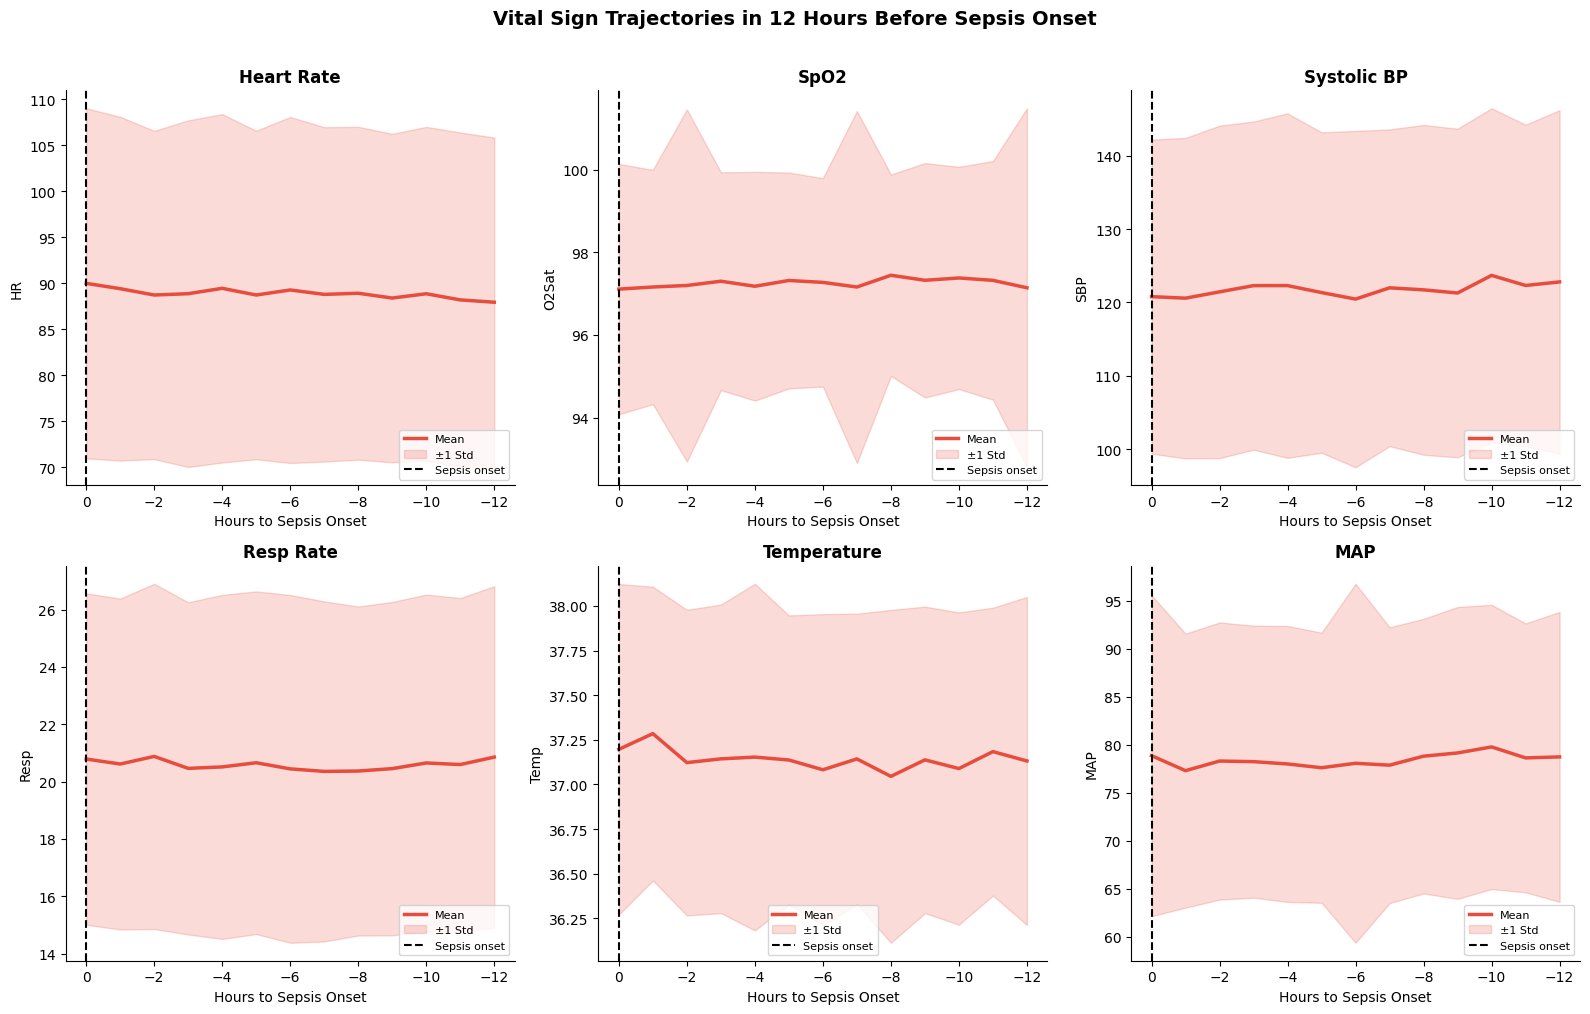

This is the temporal signal our LSTM will learn to detect!


In [11]:
# Plot vital sign trajectories leading to sepsis
key_vitals = ['HR', 'O2Sat', 'SBP', 'Resp', 'Temp', 'MAP']
vital_names = ['Heart Rate', 'SpO2', 'Systolic BP', 'Resp Rate', 'Temperature', 'MAP']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (vital, name) in enumerate(zip(key_vitals, vital_names)):
    ax = axes[i]
    
    trend = pre_sepsis_df.groupby('hours_to_sepsis')[vital].agg(['mean', 'std'])
    
    ax.plot(trend.index, trend['mean'], color='#e74c3c', linewidth=2.5, label='Mean')
    ax.fill_between(
        trend.index,
        trend['mean'] - trend['std'],
        trend['mean'] + trend['std'],
        alpha=0.2, color='#e74c3c', label='±1 Std'
    )
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Sepsis onset')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Hours to Sepsis Onset')
    ax.set_ylabel(vital)
    ax.legend(fontsize=8)
    ax.invert_xaxis()

plt.suptitle('Vital Sign Trajectories in 12 Hours Before Sepsis Onset', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../research/notes/eda_pre_sepsis_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('This is the temporal signal our LSTM will learn to detect!')

## 7. Correlation Analysis

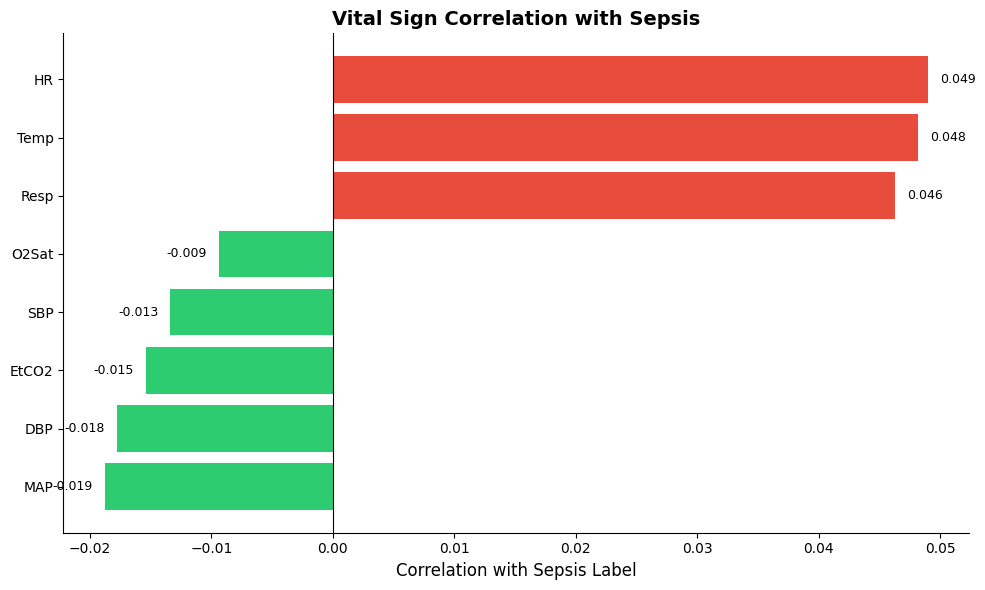


Top predictors of sepsis (by correlation):
HR       0.048987
Temp     0.048160
Resp     0.046304
MAP      0.018796
DBP      0.017757
EtCO2    0.015416
SBP      0.013375
O2Sat    0.009338
Name: SepsisLabel, dtype: float64


In [12]:
# Correlation between vitals and sepsis label
corr_data = df[VITALS + [TARGET]].dropna(subset=VITALS, how='all')
correlations = corr_data.corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with Sepsis Label', fontsize=12)
ax.set_title('Vital Sign Correlation with Sepsis', fontsize=14, fontweight='bold')

for i, (idx, val) in enumerate(correlations.items()):
    ax.text(val + 0.001 if val >= 0 else val - 0.001, i, 
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('../research/notes/eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop predictors of sepsis (by correlation):')
print(correlations.abs().sort_values(ascending=False))

## 8. ICU Stay Length Analysis

=== ICU STAY DURATION (hours) ===
             count  mean   std  min   25%   50%   75%    max
No Sepsis  37404.0  35.9  15.8  7.0  23.0  38.0  45.0  335.0
Sepsis      2932.0  57.8  59.2  7.0  14.0  36.5  80.0  335.0


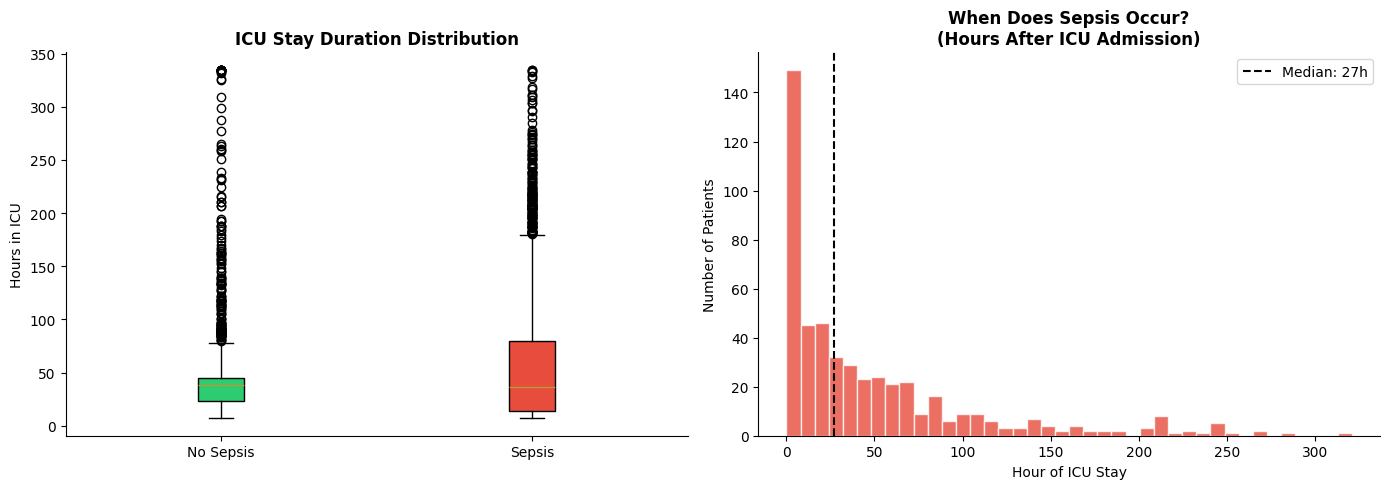

In [13]:
# ICU stay statistics
icu_stats = patient_summary.groupby('sepsis_label')['icu_hours'].describe()
icu_stats.index = ['No Sepsis', 'Sepsis']
print('=== ICU STAY DURATION (hours) ===')
print(icu_stats.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
data_to_plot = [
    patient_summary[patient_summary['sepsis_label']==0]['icu_hours'].dropna(),
    patient_summary[patient_summary['sepsis_label']==1]['icu_hours'].dropna()
]
bp = axes[0].boxplot(data_to_plot, labels=['No Sepsis', 'Sepsis'], 
                      patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[0].set_ylabel('Hours in ICU')
axes[0].set_title('ICU Stay Duration Distribution', fontsize=12, fontweight='bold')

# Sepsis onset timing
sepsis_onset_hours = pre_sepsis_df.groupby('patient_id').apply(
    lambda x: x[x['SepsisLabel']==1]['hour'].min()
).dropna()

axes[1].hist(sepsis_onset_hours, bins=40, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Hour of ICU Stay')
axes[1].set_ylabel('Number of Patients')
axes[1].set_title('When Does Sepsis Occur?\n(Hours After ICU Admission)', 
                   fontsize=12, fontweight='bold')
axes[1].axvline(x=sepsis_onset_hours.median(), color='black', 
                linestyle='--', label=f'Median: {sepsis_onset_hours.median():.0f}h')
axes[1].legend()

plt.tight_layout()
plt.savefig('../research/notes/eda_icu_stay.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. EDA Summary & Key Findings

In [14]:
print('=' * 55)
print('       ICU-WATCH EDA — KEY FINDINGS SUMMARY')
print('=' * 55)

print(f'''
📊 DATASET
   Total patients:     {df['patient_id'].nunique():,}
   Total hourly rows:  {len(df):,}
   Sepsis rate:        {sepsis_rate:.1f}% ({n_sepsis:,} patients)
   Class imbalance:    1:{n_no_sepsis//n_sepsis} (needs SMOTE or weighted loss)

🔬 MISSING DATA
   Vitals missing:     {df[VITALS].isnull().mean().mean()*100:.1f}% avg
   Labs missing:       {df[LAB_VALUES].isnull().mean().mean()*100:.1f}% avg
   Strategy:           Forward-fill (max 2h) + median imputation

📈 TOP VITAL PREDICTORS (by correlation)
   {correlations.abs().sort_values(ascending=False).head(3).to_string()}

⏱️ TEMPORAL INSIGHT
   Median sepsis onset: Hour {sepsis_onset_hours.median():.0f} after ICU admission
   Detectable signal:   12h before onset in HR, Resp, SpO2
   
🎯 MODELING IMPLICATIONS
   ✅ Use 12-hour rolling windows as LSTM input
   ✅ Weight loss function for class imbalance
   ✅ Forward-fill vitals, drop high-missing labs
   ✅ Focus features: HR, Resp, SpO2, SBP, MAP, Temp
   ✅ Prediction horizon: 6 hours before onset
''')
print('=' * 55)
print('Next step: notebooks/02_feature_engineering.ipynb')

       ICU-WATCH EDA — KEY FINDINGS SUMMARY

📊 DATASET
   Total patients:     40,336
   Total hourly rows:  1,552,210
   Sepsis rate:        7.3% (2,932 patients)
   Class imbalance:    1:12 (needs SMOTE or weighted loss)

🔬 MISSING DATA
   Vitals missing:     32.4% avg
   Labs missing:       94.2% avg
   Strategy:           Forward-fill (max 2h) + median imputation

📈 TOP VITAL PREDICTORS (by correlation)
   HR      0.048987
Temp    0.048160
Resp    0.046304

⏱️ TEMPORAL INSIGHT
   Median sepsis onset: Hour 27 after ICU admission
   Detectable signal:   12h before onset in HR, Resp, SpO2
   
🎯 MODELING IMPLICATIONS
   ✅ Use 12-hour rolling windows as LSTM input
   ✅ Weight loss function for class imbalance
   ✅ Forward-fill vitals, drop high-missing labs
   ✅ Focus features: HR, Resp, SpO2, SBP, MAP, Temp
   ✅ Prediction horizon: 6 hours before onset

Next step: notebooks/02_feature_engineering.ipynb


In [15]:
# Save processed dataframe for next notebook
save_path = Path('../data/processed')
save_path.mkdir(parents=True, exist_ok=True)

df.to_parquet(save_path / 'full_dataset.parquet', index=False)
patient_summary.to_parquet(save_path / 'patient_summary.parquet', index=False)

print(f'Saved full_dataset.parquet — {len(df):,} rows')
print(f'Saved patient_summary.parquet — {len(patient_summary):,} patients')
print('Ready for feature engineering notebook!')

Saved full_dataset.parquet — 1,552,210 rows
Saved patient_summary.parquet — 40,336 patients
Ready for feature engineering notebook!
